## Executive Report — Q1 and Q2

### Objetivo
Presentar de forma ejecutiva los hallazgos clave sobre:

1. Productos y categorías líderes por volumen e ingresos.
2. Principal dolor del cliente y focos prioritarios de intervención.

### Mensaje central
- El negocio está impulsado por pocas categorías de alta escala.
- El principal deterioro de experiencia proviene de retrasos en entrega.
- Existen además focos secundarios de dolor no logístico en algunas categorías específicas.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets

In [2]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
order_items = bundle.order_items.copy()
order_payments = bundle.order_payments.copy()
order_reviews = bundle.order_reviews.copy()
orders = bundle.orders.copy()
products = bundle.products.copy()
translation = bundle.product_category_translation.copy()
sellers = bundle.sellers.copy()

In [3]:
reviews_agg = (
    order_reviews
    .sort_values(["order_id", "review_creation_date"], ascending=[True, False], na_position="last")
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_comment_title=("review_comment_title", "first"),
        review_comment_message=("review_comment_message", "first"),
    )
)

delivered_orders = orders.loc[orders["order_status"] == "delivered"].copy()

item_base = (
    order_items
    .merge(delivered_orders, on="order_id", how="inner", validate="many_to_one")
    .merge(products, on="product_id", how="left", validate="many_to_one")
    .merge(translation, on="product_category_name", how="left", validate="many_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(sellers, on="seller_id", how="left", validate="many_to_one")
    .merge(reviews_agg, on="order_id", how="left", validate="many_to_one")
)

item_base["product_category"] = (
    item_base["product_category_name_english"]
    .fillna(item_base["product_category_name"])
    .fillna("unknown")
)

item_base["quantity"] = 1
item_base["item_revenue"] = item_base["price"].fillna(0.0)
item_base["gross_revenue"] = item_base["price"].fillna(0.0) + item_base["freight_value"].fillna(0.0)
item_base["delivery_delay_days"] = (
    item_base["order_delivered_customer_date"] - item_base["order_estimated_delivery_date"]
).dt.days
item_base["is_late_delivery"] = item_base["delivery_delay_days"] > 0
item_base["is_bad_review"] = item_base["review_score"].fillna(5) <= 2
item_base["is_neutral_or_worse_review"] = item_base["review_score"].fillna(5) <= 3

In [4]:
product_sales = (
    item_base.groupby("product_id", as_index=False)
    .agg(
        product_category=("product_category", lambda s: s.mode().iloc[0] if not s.mode().empty else "unknown"),
        total_volume=("quantity", "sum"),
        total_revenue=("item_revenue", "sum"),
        n_orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
    )
)

category_sales = (
    item_base.groupby("product_category", as_index=False)
    .agg(
        total_volume=("quantity", "sum"),
        total_revenue=("item_revenue", "sum"),
        n_orders=("order_id", "nunique"),
        n_products=("product_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
    )
)

In [5]:
top_categories_volume = (
    category_sales.sort_values(["total_volume", "total_revenue"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_categories_revenue = (
    category_sales.sort_values(["total_revenue", "total_volume"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_products_volume = (
    product_sales.sort_values(["total_volume", "total_revenue"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_products_revenue = (
    product_sales.sort_values(["total_revenue", "total_volume"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

In [6]:
delay_review_summary = (
    item_base.groupby("is_late_delivery", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
    )
)

category_diagnostics = (
    item_base.groupby("product_category", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
    )
)

worst_categories_general = (
    category_diagnostics
    .query("n_orders >= 30")
    .sort_values(["bad_review_rate", "late_delivery_rate", "avg_review_score"], ascending=[False, False, True])
    .reset_index(drop=True)
)

on_time_category_diagnostics = (
    item_base.loc[~item_base["is_late_delivery"]]
    .groupby("product_category", as_index=False)
    .agg(
        n_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
    )
    .query("n_orders >= 30")
    .sort_values(["bad_review_rate", "avg_review_score"], ascending=[False, True])
    .reset_index(drop=True)
)

high_impact_bad_products = (
    item_base.groupby("product_id", as_index=False)
    .agg(
        product_category=("product_category", lambda s: s.mode().iloc[0] if not s.mode().empty else "unknown"),
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
    )
    .query("n_orders >= 20")
    .sort_values(["bad_review_rate", "total_revenue", "n_items"], ascending=[False, False, False])
    .reset_index(drop=True)
)

### 1. Executive summary

In [7]:
executive_summary = pd.DataFrame({
    "kpi": [
        "Top category by volume",
        "Top category by revenue",
        "Bad review rate - on time",
        "Bad review rate - late",
        "Average review score - on time",
        "Average review score - late",
    ],
    "value": [
        top_categories_volume.loc[0, "product_category"],
        top_categories_revenue.loc[0, "product_category"],
        delay_review_summary.loc[delay_review_summary["is_late_delivery"] == False, "bad_review_rate"].iloc[0],
        delay_review_summary.loc[delay_review_summary["is_late_delivery"] == True, "bad_review_rate"].iloc[0],
        delay_review_summary.loc[delay_review_summary["is_late_delivery"] == False, "avg_review_score"].iloc[0],
        delay_review_summary.loc[delay_review_summary["is_late_delivery"] == True, "avg_review_score"].iloc[0],
    ]
})

executive_summary

,kpi,value
0,Top category by volume,bed_bath_table
1,Top category by revenue,health_beauty
2,Bad review rate - on time,0.11
3,Bad review rate - late,0.61
4,Average review score - on time,4.21
5,Average review score - late,2.26


### 2. Q1 — Las categorías que mueven el negocio

In [9]:
q1_categories = category_sales.copy()
q1_categories["volume_share_pct"] = q1_categories["total_volume"] / q1_categories["total_volume"].sum() * 100
q1_categories["revenue_share_pct"] = q1_categories["total_revenue"] / q1_categories["total_revenue"].sum() * 100

q1_top = (
    q1_categories
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

q1_top[["product_category", "total_volume", "volume_share_pct", "total_revenue", "revenue_share_pct"]]

,product_category,total_volume,volume_share_pct,total_revenue,revenue_share_pct
0,health_beauty,9465,8.59,"1,233,131.72",9.33
1,watches_gifts,5859,5.32,"1,166,176.98",8.82
2,bed_bath_table,10953,9.94,"1,023,434.76",7.74
3,sports_leisure,8431,7.65,"954,852.55",7.22
4,computers_accessories,7644,6.94,"888,724.61",6.72
5,furniture_decor,8160,7.40,"711,927.69",5.38
6,housewares,6795,6.17,"615,628.69",4.66
7,cool_stuff,3718,3.37,"610,204.10",4.62
8,auto,4140,3.76,"578,966.65",4.38
9,toys,4030,3.66,"471,286.48",3.56


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def fmt_int(x, pos=None):
    return f"{x:,.0f}"

def fmt_currency(x, pos=None):
    return f"${x:,.0f}"

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

TP_COLORS = {
    "blue_primary": "#163E9F",   # azul rey principal
    "blue_secondary": "#2F6BFF", # azul de apoyo
    "blue_soft": "#6EC1E4",      # celeste del branding
    "yellow_accent": "#F2D22E",  # amarillo acento
    "gray_bg": "#F3F4F6",        # gris claro fondo
    "gray_text": "#4B5563",      # gris texto secundario
    "gray_muted": "#D1D5DB",     # gris líneas suaves
    "white": "#FFFFFF",
}


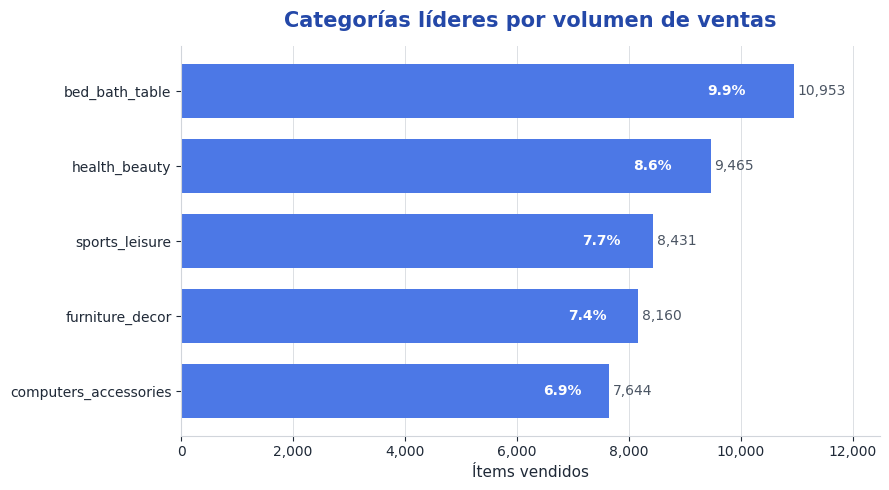

In [ ]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

TP_COLORS = {
    "blue_primary": "#2448A8",   # azul rey suavizado
    "blue_secondary": "#4C78E6", # azul apoyo
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_int(x, pos=None):
    return f"{x:,.0f}"

plot_df = top_categories_volume.copy().sort_values("total_volume", ascending=True)
total_volume_all = category_sales["total_volume"].sum()
plot_df["share_pct"] = plot_df["total_volume"] / total_volume_all

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

bars = ax.barh(
    plot_df["product_category"],
    plot_df["total_volume"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72,
)

ax.set_title("Categorías líderes por volumen de ventas", fontsize=15, fontweight="bold", color=TP_COLORS["blue_primary"], pad=14)
ax.set_xlabel("Ítems vendidos", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("", fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int))

# estilo ejes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_muted"])
ax.spines["bottom"].set_color(TP_COLORS["gray_muted"])
ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"])
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"])

# grid suave solo en x
ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["total_volume"].max()

for i, (_, row) in enumerate(plot_df.iterrows()):
    value = row["total_volume"]
    pct = row["share_pct"]

    # porcentaje dentro de la barra
    pct_label = f"{pct:.1%}"
    inside_x = value * 0.89 
    ax.text(
        inside_x,
        i,
        pct_label,
        va="center",
        ha="center",
        color=TP_COLORS["white"],
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=TP_COLORS["blue_secondary"],
            edgecolor="none"
        )
    )

    # valor absoluto al final de la barra
    ax.text(
        value + max_val * 0.006,
        i,
        f"{value:,.0f}",
        va="center",
        ha="left",
        color=TP_COLORS["gray_text"],
        fontsize=10,
        fontweight="normal"
    )

ax.set_xlim(0, max_val * 1.14)

plt.tight_layout()
plt.show()

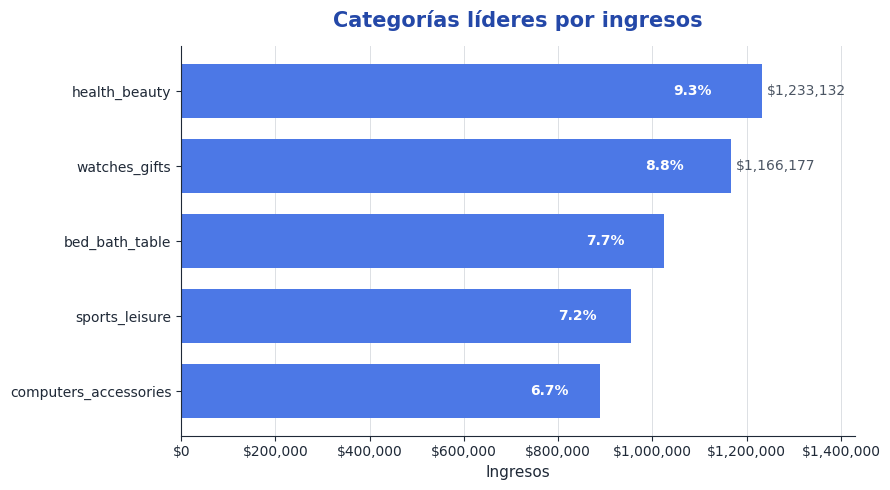

In [69]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

TP_COLORS = {
    "blue_primary": "#2448A8",   # azul rey suavizado
    "blue_secondary": "#4C78E6", # azul apoyo
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_currency(x, pos=None):
    return f"${x:,.0f}"

plot_df = top_categories_revenue.copy().sort_values("total_revenue", ascending=True)
total_revenue_all = category_sales["total_revenue"].sum()
plot_df["share_pct"] = plot_df["total_revenue"] / total_revenue_all

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

bars = ax.barh(
    plot_df["product_category"],
    plot_df["total_revenue"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72,
)

ax.set_title(
    "Categorías líderes por ingresos",
    fontsize=15,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("Ingresos", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("", fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_currency))

# estilo ejes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# grid suave solo en x
ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["total_revenue"].max()
top_two_idx = plot_df.index[-2:]  # últimas dos filas = top 2 por ingreso

for i, (idx, row) in enumerate(plot_df.iterrows()):
    value = row["total_revenue"]
    pct = row["share_pct"]

    # porcentaje dentro de la barra
    pct_label = f"{pct:.1%}"
    inside_x = value * 0.88

    ax.text(
        inside_x,
        i,
        pct_label,
        va="center",
        ha="center",
        color=TP_COLORS["white"],
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=TP_COLORS["blue_secondary"],
            edgecolor="none"
        )
    )

    # valor absoluto afuera solo para top 2
    if idx in top_two_idx:
        ax.text(
            value + max_val * 0.008,
            i,
            f"${value:,.0f}",
            va="center",
            ha="left",
            color=TP_COLORS["gray_text"],
            fontsize=10,
            fontweight="normal"
        )

# margen derecho para que respiren las dos etiquetas externas
ax.set_xlim(0, max_val * 1.16)

plt.tight_layout()
plt.show()

## 3. Q1 — Productos líderes
Nota: como el dataset no trae nombre comercial, se reportan por `product_id`.


In [12]:
top_products_volume[["product_id", "product_category", "total_volume", "total_revenue", "avg_review_score"]]

,product_id,product_category,total_volume,total_revenue,avg_review_score
0,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,520,"37,104.30",4.05
1,422879e10f46682990de24d770e7f83d,garden_tools,484,"26,577.22",3.96
2,99a4788cb24856965c36a24e339b6058,bed_bath_table,477,"42,049.66",3.93
3,389d119b48cf3043d311335e499d9c6b,garden_tools,390,"21,336.79",4.13
4,368c6c730842d78016ad823897a372db,garden_tools,388,"21,056.80",3.92


In [13]:
top_products_revenue[["product_id", "product_category", "total_revenue", "total_volume", "avg_review_score"]]

,product_id,product_category,total_revenue,total_volume,avg_review_score
0,bb50f2e236e5eea0100680137654686c,health_beauty,"63,560.00",194,4.24
1,6cdd53843498f92890544667809f1595,health_beauty,"53,652.30",153,4.36
2,d6160fb7873f184099d9bc95e30376af,computers,"45,949.35",33,4.67
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,"45,620.56",332,4.28
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,"42,049.66",477,3.93


## 4. Q2 — Evidencia del mayor dolor del cliente

In [14]:
delay_view = delay_review_summary.copy()
delay_view["scenario"] = delay_view["is_late_delivery"].map({False: "On time", True: "Late"})
delay_view[["scenario", "n_items", "avg_review_score", "bad_review_rate", "neutral_or_worse_rate"]]

,scenario,n_items,avg_review_score,bad_review_rate,neutral_or_worse_rate
0,On time,102933,4.21,0.11,0.20
1,Late,7264,2.26,0.61,0.72


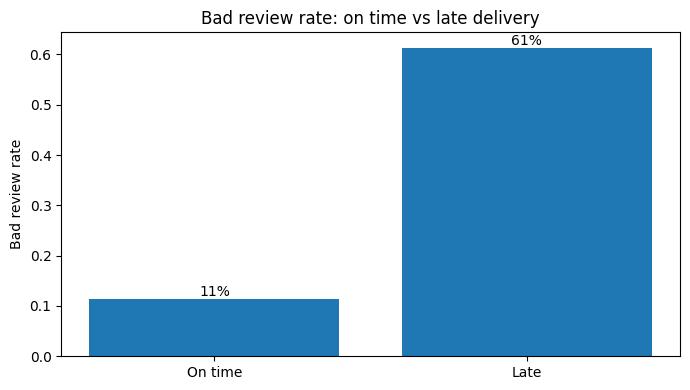

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(delay_view["scenario"], delay_view["bad_review_rate"])
ax.set_title("Bad review rate: on time vs late delivery")
ax.set_xlabel("")
ax.set_ylabel("Bad review rate")

for i, v in enumerate(delay_view["bad_review_rate"]):
    ax.text(i, v, f"{v:.0%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

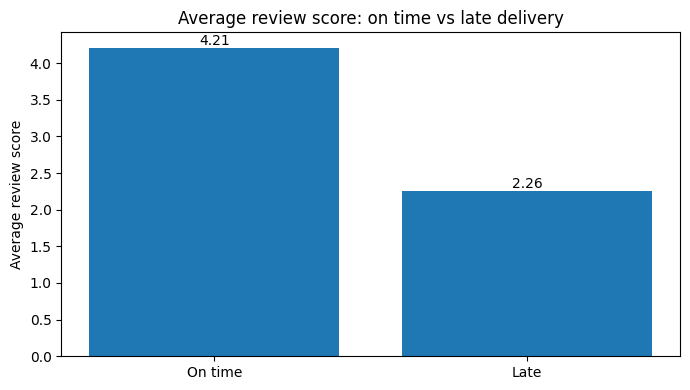

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(delay_view["scenario"], delay_view["avg_review_score"])
ax.set_title("Average review score: on time vs late delivery")
ax.set_xlabel("")
ax.set_ylabel("Average review score")

for i, v in enumerate(delay_view["avg_review_score"]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

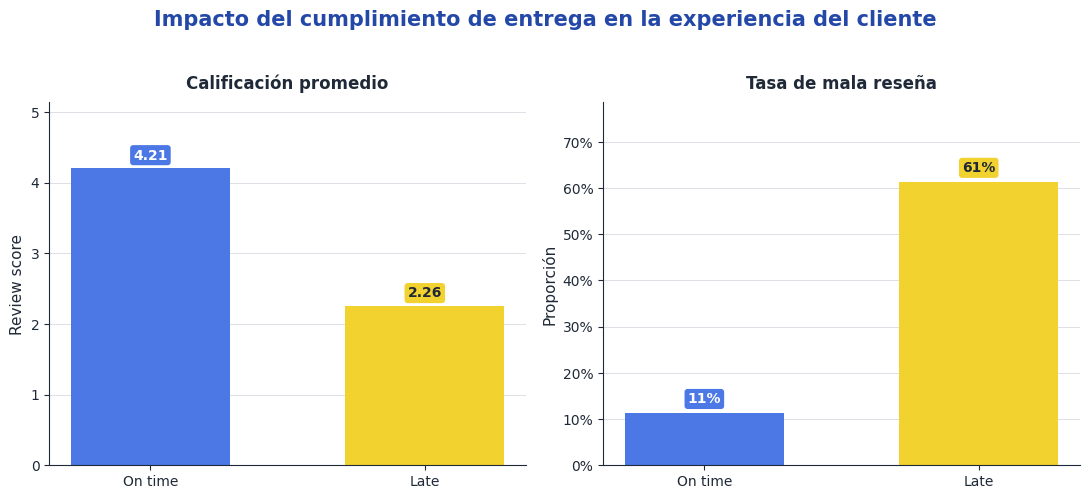

In [72]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd


def fmt_pct(x, pos=None):
    return f"{x:.0%}"

plot_df = delay_view.copy()
plot_df["scenario"] = pd.Categorical(
    plot_df["scenario"],
    categories=["On time", "Late"],
    ordered=True
)
plot_df = plot_df.sort_values("scenario").reset_index(drop=True)

bar_colors = [TP_COLORS["blue_secondary"], TP_COLORS["yellow_accent"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), facecolor=TP_COLORS["white"])
fig.suptitle(
    "Impacto del cumplimiento de entrega en la experiencia del cliente",
    fontsize=15,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    y=1.03
)

# =========================
# Subplot 1: tasa de mala reseña
# =========================
ax = axes[1]
ax.set_facecolor(TP_COLORS["white"])

bars = ax.bar(
    plot_df["scenario"],
    plot_df["bad_review_rate"],
    color=bar_colors,
    edgecolor="none",
    width=0.58
)

ax.set_title(
    "Tasa de mala reseña",
    fontsize=12,
    fontweight="bold",
    color=TP_COLORS["gray_dark"],
    pad=10
)
ax.set_xlabel("")
ax.set_ylabel("Proporción", color=TP_COLORS["gray_dark"], fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))

# estilo ejes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("normal")
for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# grid suave solo en y
ax.yaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

for i, v in enumerate(plot_df["bad_review_rate"]):
    label_color = TP_COLORS["white"] if i == 0 else TP_COLORS["gray_dark"]
    ax.text(
        i,
        v + 0.015,
        f"{v:.0%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=label_color,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=bar_colors[i],
            edgecolor="none"
        )
    )

ax.set_ylim(0, max(plot_df["bad_review_rate"]) * 1.28)

# =========================
# Subplot 2: calificación promedio
# =========================
ax = axes[0]
ax.set_facecolor(TP_COLORS["white"])

bars = ax.bar(
    plot_df["scenario"],
    plot_df["avg_review_score"],
    color=bar_colors,
    edgecolor="none",
    width=0.58
)

ax.set_title(
    "Calificación promedio",
    fontsize=12,
    fontweight="bold",
    color=TP_COLORS["gray_dark"],
    pad=10
)
ax.set_xlabel("")
ax.set_ylabel("Review score", color=TP_COLORS["gray_dark"], fontsize=11)

# estilo ejes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("normal")
for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# grid suave solo en y
ax.yaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

for i, v in enumerate(plot_df["avg_review_score"]):
    label_color = TP_COLORS["white"] if i == 0 else TP_COLORS["gray_dark"]
    ax.text(
        i,
        v + 0.08,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=label_color,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=bar_colors[i],
            edgecolor="none"
        )
    )

ax.set_ylim(0, max(plot_df["avg_review_score"]) * 1.22)

plt.tight_layout()
plt.show()

## 5. Q2 — Categorías a priorizar
Se tiene en cuenta dos dimensiones:
- escala del problema
- severidad de la experiencia

In [17]:
priority_categories = (
    category_diagnostics
    .query("n_orders >= 30")
    .assign(
        pain_index=lambda df: df["bad_review_rate"] * np.log1p(df["n_items"])
    )
    .sort_values(["pain_index", "total_revenue"], ascending=[False, False])
    .reset_index(drop=True)
)

priority_categories.head(15)

,product_category,n_items,n_orders,total_revenue,avg_review_score,bad_review_rate,late_delivery_rate,pain_index
0,office_furniture,1668,1254,"268,154.31",3.51,0.25,0.08,1.87
1,bed_bath_table,10953,9272,"1,023,434.76",3.92,0.18,0.07,1.66
2,furniture_decor,8160,6307,"711,927.69",3.95,0.18,0.07,1.60
3,computers_accessories,7644,6530,"888,724.61",3.99,0.17,0.06,1.51
4,unknown,1537,1392,"170,726.63",3.94,0.19,0.07,1.41
5,telephony,4430,4093,"309,860.23",3.99,0.15,0.07,1.30
6,watches_gifts,5859,5495,"1,166,176.98",4.07,0.15,0.07,1.27
7,fixed_telephony,255,212,"55,315.21",3.76,0.23,0.04,1.26
8,audio,362,348,"50,570.60",3.84,0.21,0.12,1.25
9,housewares,6795,5743,"615,628.69",4.11,0.14,0.05,1.24


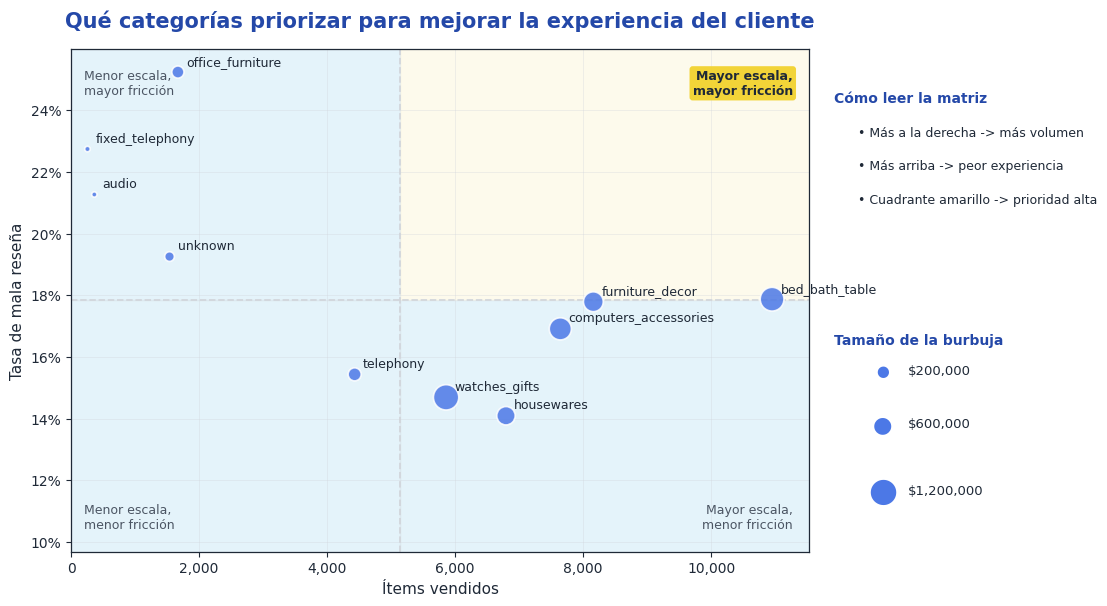

In [96]:
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_int(x, pos=None):
    return f"{x:,.0f}"

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

plot_df = priority_categories.head(10).copy()

# =========================
# Referencias para cuadrantes
# =========================
x_ref = plot_df["n_items"].median()
y_ref = plot_df["bad_review_rate"].median()

# Límites simétricos alrededor de las referencias
x_left = x_ref - plot_df["n_items"].min()
x_right = plot_df["n_items"].max() - x_ref
x_half_range = max(x_left, x_right) * 1.10

y_down = y_ref - plot_df["bad_review_rate"].min()
y_up = plot_df["bad_review_rate"].max() - y_ref
y_half_range = max(y_down, y_up) * 1.10

x_min = max(0, x_ref - x_half_range)
x_max = x_ref + x_half_range
y_min = max(0, y_ref - y_half_range)
y_max = y_ref + y_half_range

# =========================
# Tamaño de burbujas
# =========================
size_scale = 3500
sizes = plot_df["total_revenue"] / size_scale

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(12.2, 6.7), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

# Espacio a la derecha para convenciones
fig.subplots_adjust(right=0.73, top=0.86)

# =========================
# Cuadrantes con bounding box
# =========================
quad_alpha_blue = 0.18
quad_alpha_yellow = 0.09
quad_edge = TP_COLORS["gray_muted"]

# inferior izquierdo
ax.add_patch(Rectangle(
    (x_min, y_min),
    x_ref - x_min,
    y_ref - y_min,
    facecolor=TP_COLORS["blue_soft"],
    edgecolor=quad_edge,
    linewidth=1.0,
    alpha=quad_alpha_blue,
    zorder=0
))

# superior izquierdo
ax.add_patch(Rectangle(
    (x_min, y_ref),
    x_ref - x_min,
    y_max - y_ref,
    facecolor=TP_COLORS["blue_soft"],
    edgecolor=quad_edge,
    linewidth=1.0,
    alpha=quad_alpha_blue,
    zorder=0
))

# inferior derecho
ax.add_patch(Rectangle(
    (x_ref, y_min),
    x_max - x_ref,
    y_ref - y_min,
    facecolor=TP_COLORS["blue_soft"],
    edgecolor=quad_edge,
    linewidth=1.0,
    alpha=quad_alpha_blue,
    zorder=0
))

# superior derecho = prioridad alta
ax.add_patch(Rectangle(
    (x_ref, y_ref),
    x_max - x_ref,
    y_max - y_ref,
    facecolor=TP_COLORS["yellow_accent"],
    edgecolor=quad_edge,
    linewidth=1.0,
    alpha=quad_alpha_yellow,
    zorder=0
))

# =========================
# Scatter
# =========================
ax.scatter(
    plot_df["n_items"],
    plot_df["bad_review_rate"],
    s=sizes,
    color=TP_COLORS["blue_secondary"],
    alpha=0.85,
    edgecolors=TP_COLORS["white"],
    linewidths=1.2,
    zorder=3
)

# Etiquetas
for _, row in plot_df.iterrows():
    ax.annotate(
        row["product_category"],
        (row["n_items"], row["bad_review_rate"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
        color=TP_COLORS["gray_dark"]
    )

# Líneas de referencia
ax.axvline(x_ref, color=TP_COLORS["gray_muted"], linestyle="--", linewidth=1.25, zorder=1)
ax.axhline(y_ref, color=TP_COLORS["gray_muted"], linestyle="--", linewidth=1.25, zorder=1)

# =========================
# Título
# =========================
ax.set_title(
    "Qué categorías priorizar para mejorar la experiencia del cliente",
    fontsize=15,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=16
)

# =========================
# Ejes
# =========================
ax.set_xlabel("Ítems vendidos", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("Tasa de mala reseña", color=TP_COLORS["gray_dark"], fontsize=11)

ax.xaxis.set_major_formatter(FuncFormatter(fmt_int))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Bordes completos en los 4 lados
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color(TP_COLORS["gray_dark"])
    ax.spines[side].set_linewidth(0.9)

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("normal")
for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# Grid suave
ax.grid(True, linestyle="-", linewidth=0.6, color=TP_COLORS["gray_muted"], alpha=0.40)
ax.set_axisbelow(True)

# =========================
# Labels internos de cuadrantes
# =========================
ax.text(
    x_min + (x_ref - x_min) * 0.04,
    y_max - (y_max - y_ref) * 0.08,
    "Menor escala,\nmayor fricción",
    fontsize=9,
    color=TP_COLORS["gray_text"],
    ha="left",
    va="top"
)

ax.text(
    x_ref + (x_max - x_ref) * 0.96,
    y_max - (y_max - y_ref) * 0.08,
    "Mayor escala,\nmayor fricción",
    fontsize=9,
    color=TP_COLORS["gray_dark"],
    ha="right",
    va="top",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=TP_COLORS["yellow_accent"],
        edgecolor="none",
        alpha=0.95
    )
)

ax.text(
    x_min + (x_ref - x_min) * 0.04,
    y_min + (y_ref - y_min) * 0.08,
    "Menor escala,\nmenor fricción",
    fontsize=9,
    color=TP_COLORS["gray_text"],
    ha="left",
    va="bottom"
)

ax.text(
    x_ref + (x_max - x_ref) * 0.96,
    y_min + (y_ref - y_min) * 0.08,
    "Mayor escala,\nmenor fricción",
    fontsize=9,
    color=TP_COLORS["gray_text"],
    ha="right",
    va="bottom"
)

# =========================
# Convenciones a la derecha
# =========================
fig.text(
    0.75, 0.78,
    "Cómo leer la matriz",
    fontsize=10,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    ha="left"
)

fig.text(
    0.77, 0.73,
    "• Más a la derecha -> más volumen",
    fontsize=9.0,
    color=TP_COLORS["gray_dark"],
    ha="left"
)

fig.text(
    0.77, 0.68,
    "• Más arriba -> peor experiencia",
    fontsize=9.0,
    color=TP_COLORS["gray_dark"],
    ha="left"
)

fig.text(
    0.77, 0.63,
    "• Cuadrante amarillo -> prioridad alta",
    fontsize=9.0,
    color=TP_COLORS["gray_dark"],
    ha="left"
)

# =========================
# Convención tamaño de burbuja
# =========================
fig.text(
    0.75, 0.42,
    "Tamaño de la burbuja" ,
    fontsize=10,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    ha="left"
)

# mini eje manual vertical para tamaños
bubble_levels = [200000, 600000, 1200000]
bubble_y = [0.38, 0.30, 0.20]

for y, val in zip(bubble_y, bubble_levels):
    ax.scatter(
        [], [],  # dummy para mantener consistencia mental; no se dibuja en axes
    )

# Dibujar burbujas con otro axes invisible en coordenadas de figura
for y, val in zip(bubble_y, bubble_levels):
    fig.text(
        0.790, y,
        "●",
        fontsize=8 + (val / 1200000) * 16,
        color=TP_COLORS["blue_secondary"],
        ha="center",
        va="center"
    )
    fig.text(
        0.811, y,
        f"${val:,.0f}",
        fontsize=9.5,
        color=TP_COLORS["gray_dark"],
        ha="left",
        va="center"
    )

plt.show()

## 6. Q2 — Dolor secundario no logístico
Estas categorías mantienen mala experiencia incluso cuando la entrega no fue tardía.

In [20]:
on_time_category_diagnostics.head(10)

,product_category,n_orders,total_revenue,avg_review_score,bad_review_rate
0,office_furniture,1153,"246,403.14",3.62,0.22
1,fashion_male_clothing,101,"9,892.93",3.86,0.22
2,party_supplies,38,"4,465.19",3.83,0.21
3,fixed_telephony,202,"52,055.33",3.83,0.21
4,home_confort,355,"53,170.39",4.02,0.16
5,unknown,1291,"156,594.71",4.09,0.15
6,construction_tools_safety,155,"38,443.47",4.05,0.15
7,furniture_decor,5858,"653,411.75",4.07,0.15
8,home_construction,454,"75,604.74",4.06,0.15
9,bed_bath_table,8583,"944,199.66",4.05,0.14


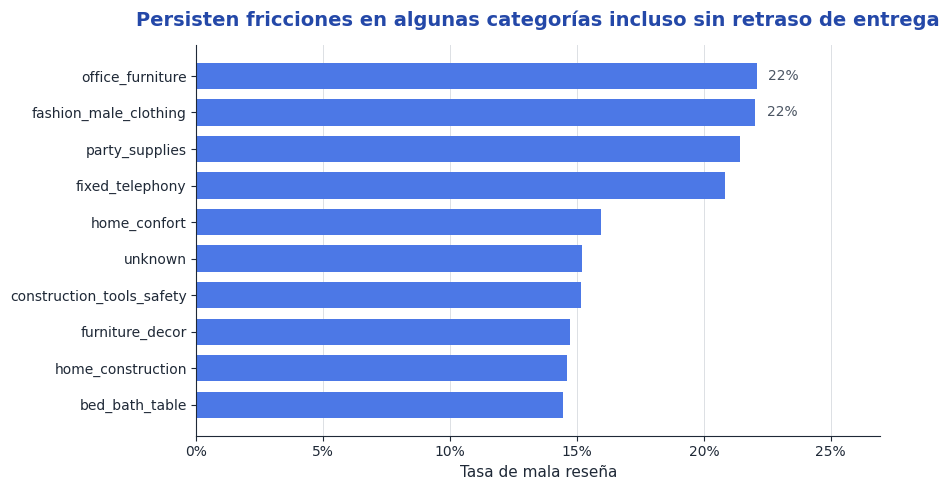

In [99]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

TP_COLORS = {
    "blue_primary": "#2448A8",   # azul rey suavizado
    "blue_secondary": "#4C78E6", # azul apoyo
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

plot_df = on_time_category_diagnostics.head(10).sort_values("bad_review_rate", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

bars = ax.barh(
    plot_df["product_category"],
    plot_df["bad_review_rate"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72,
)

ax.set_title(
    "Persisten fricciones en algunas categorías incluso sin retraso de entrega",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)

ax.set_xlabel("Tasa de mala reseña", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("", fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_pct))

# estilo ejes
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("normal")

for label in ax.get_yticklabels():
    label.set_fontweight("normal")

# grid suave solo en x
ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["bad_review_rate"].max()
top_two_idx = plot_df.index[-2:]  # las dos categorías con mayor bad_review_rate dentro del top mostrado

for i, (idx, row) in enumerate(plot_df.iterrows()):
    value = row["bad_review_rate"]

    # porcentaje dentro de la barra
    inside_x = value * 0.86
    ax.text(
        inside_x,
        i,
        f"{value:.0%}",
        va="center",
        ha="center",
        color=TP_COLORS["blue_secondary"],
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor=TP_COLORS["blue_secondary"],
            edgecolor="none"
        )
    )

    # valor externo solo para las 2 categorías más altas
    if idx in top_two_idx:
        ax.text(
            value + max_val * 0.02,
            i,
            f"{value:.0%}",
            va="center",
            ha="left",
            color=TP_COLORS["gray_text"],
            fontsize=10,
            fontweight="normal"
        )

# margen derecho
ax.set_xlim(0, max_val * 1.22)

plt.tight_layout()
plt.show()

### 7. Productos de alto impacto asociados a mala experiencia

In [22]:
high_impact_bad_products.head(15)

,product_id,product_category,n_items,n_orders,total_revenue,avg_review_score,bad_review_rate,late_delivery_rate
0,cd46a885543f0e169a49f1eb25c04e43,computers_accessories,30,28,"2,999.70",1.83,0.77,0.00
1,b1d207586fca400a2370d50a9ba1da98,unknown,47,42,"7,003.00",1.91,0.74,0.11
2,89b121bee266dcd25688a1ba72eefb61,computers_accessories,63,57,"5,033.70",2.49,0.57,0.10
3,25c38557cf793876c5abdd5931f922db,baby,38,38,"38,907.32",2.68,0.53,0.21
4,7b35ccd93a2184646c03b70326626923,sports_leisure,23,20,"3,599.30",2.68,0.52,0.09
5,0cf41187284d7f099adc8415a743ebbd,baby,34,32,"1,220.60",2.91,0.50,0.18
6,51f876eb62be778c757503cf7f8a3b74,health_beauty,32,22,324.60,2.94,0.50,0.12
7,1dec4c88c685d5a07bf01dcb0f8bf9f8,auto,35,35,"19,965.00",2.74,0.49,0.37
8,362b773250263786dd58670d2df42c3b,sports_leisure,73,49,"3,782.70",2.92,0.47,0.05
9,fb01a5fc09b9b9563c2ee41a22f07d54,consoles_games,24,24,"16,731.79",2.87,0.46,0.25


In [23]:
product_story = high_impact_bad_products.head(10).copy()
product_story["bad_review_rate_pct"] = product_story["bad_review_rate"] * 100

product_story[[
    "product_id",
    "product_category",
    "n_orders",
    "total_revenue",
    "avg_review_score",
    "bad_review_rate_pct",
    "late_delivery_rate"
]]

,product_id,product_category,n_orders,total_revenue,avg_review_score,bad_review_rate_pct,late_delivery_rate
0,cd46a885543f0e169a49f1eb25c04e43,computers_accessories,28,"2,999.70",1.83,76.67,0.00
1,b1d207586fca400a2370d50a9ba1da98,unknown,42,"7,003.00",1.91,74.47,0.11
2,89b121bee266dcd25688a1ba72eefb61,computers_accessories,57,"5,033.70",2.49,57.14,0.10
3,25c38557cf793876c5abdd5931f922db,baby,38,"38,907.32",2.68,52.63,0.21
4,7b35ccd93a2184646c03b70326626923,sports_leisure,20,"3,599.30",2.68,52.17,0.09
5,0cf41187284d7f099adc8415a743ebbd,baby,32,"1,220.60",2.91,50.00,0.18
6,51f876eb62be778c757503cf7f8a3b74,health_beauty,22,324.60,2.94,50.00,0.12
7,1dec4c88c685d5a07bf01dcb0f8bf9f8,auto,35,"19,965.00",2.74,48.57,0.37
8,362b773250263786dd58670d2df42c3b,sports_leisure,49,"3,782.70",2.92,46.58,0.05
9,fb01a5fc09b9b9563c2ee41a22f07d54,consoles_games,24,"16,731.79",2.87,45.83,0.25


### 8. Redacción ejecutiva final

In [24]:
q1_narrative = f"""
Q1. Las categorías líderes por volumen e ingresos no son las mismas.
- La categoría con mayor volumen es {top_categories_volume.loc[0, "product_category"]} con {top_categories_volume.loc[0, "total_volume"]:,.0f} ítems.
- La categoría con mayores ingresos es {top_categories_revenue.loc[0, "product_category"]} con {top_categories_revenue.loc[0, "total_revenue"]:,.2f} en ingresos.
- Esto sugiere que el negocio combina categorías de alta rotación con categorías de mayor ticket promedio.
"""

print(q1_narrative)


Q1. Las categorías líderes por volumen e ingresos no son las mismas.
- La categoría con mayor volumen es bed_bath_table con 10,953 ítems.
- La categoría con mayores ingresos es health_beauty con 1,233,131.72 en ingresos.
- Esto sugiere que el negocio combina categorías de alta rotación con categorías de mayor ticket promedio.



In [25]:
late_bad = delay_view.loc[delay_view["scenario"] == "Late", "bad_review_rate"].iloc[0]
on_time_bad = delay_view.loc[delay_view["scenario"] == "On time", "bad_review_rate"].iloc[0]
late_score = delay_view.loc[delay_view["scenario"] == "Late", "avg_review_score"].iloc[0]
on_time_score = delay_view.loc[delay_view["scenario"] == "On time", "avg_review_score"].iloc[0]

q2_narrative = f"""
Q2. El principal dolor del cliente es logístico.
- La tasa de mala reseña pasa de {on_time_bad:.0%} en entregas puntuales a {late_bad:.0%} en entregas tardías.
- El review score promedio cae de {on_time_score:.2f} a {late_score:.2f}.
- Además existe un dolor secundario de producto/expectativa en categorías que siguen mostrando mala experiencia incluso sin retraso, como {on_time_category_diagnostics.loc[0, "product_category"]}, {on_time_category_diagnostics.loc[1, "product_category"]} y {on_time_category_diagnostics.loc[2, "product_category"]}.
"""

print(q2_narrative)


Q2. El principal dolor del cliente es logístico.
- La tasa de mala reseña pasa de 11% en entregas puntuales a 61% en entregas tardías.
- El review score promedio cae de 4.21 a 2.26.
- Además existe un dolor secundario de producto/expectativa en categorías que siguen mostrando mala experiencia incluso sin retraso, como office_furniture, fashion_male_clothing y party_supplies.



### 9. Supuestos y limitaciones
- Se analizaron solo órdenes entregadas.
- El ingreso por producto/categoría se calculó con `price`, no con pagos agregados.
- La review es a nivel orden; se usó como proxy a nivel ítem.
- Los comentarios de texto se usaron solo como apoyo cualitativo.